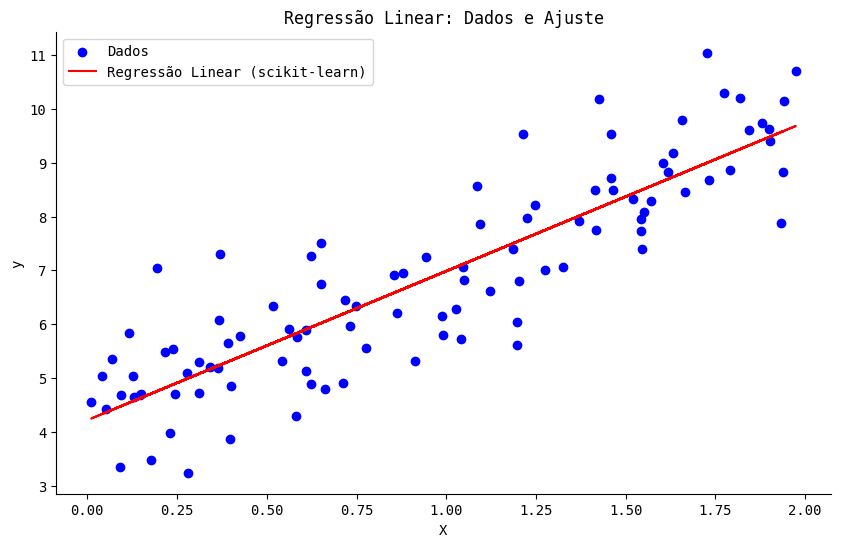

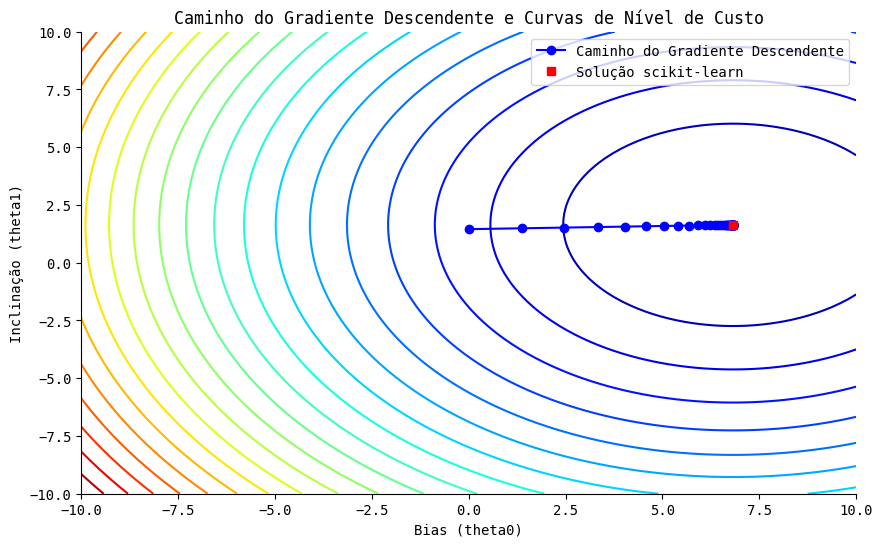

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Normalizar os dados (recomendado para gradiente descendente)
scaler = StandardScaler()  # Coloca os dados em dist normal
X_scaled = scaler.fit_transform(X)

# Gradiente Descendente para Regressão Linear
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m = len(y)
    theta = np.random.randn(2, 1)  # Inicialização aleatória dos parâmetros
    X_b = np.c_[np.ones((m, 1)), X]  # Adicionar coluna de 1s para o termo de bias
    
    theta_path = [theta]
    
    for i in range(iterations):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - learning_rate * gradients
        theta_path.append(theta)
         
    return theta, theta_path

# Ajustar o modelo e obter o histórico de parâmetros
theta_final, theta_history = gradient_descent(X_scaled, y, learning_rate=0.1, iterations=100)
theta_history = np.array(theta_history)

# Usar scikit-learn para comparação (resolução exata)
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
theta_sklearn = np.array([[lin_reg.intercept_[0]], [lin_reg.coef_[0][0]]])

# Plotar dados e regressão
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Dados')
plt.plot(X, lin_reg.predict(X_scaled), color='red', label='Regressão Linear (scikit-learn)')
plt.title('Regressão Linear: Dados e Ajuste')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Visualizar o Gradiente Descendente com Curvas de Nível
plt.figure(figsize=(10, 6))

# Criar uma malha de parâmetros para calcular o custo (erro quadrático médio)
t0 = np.linspace(-10, 10, 100)
t1 = np.linspace(-10, 10, 100)
T0, T1 = np.meshgrid(t0, t1)
m = len(y)
X_b_scaled = np.c_[np.ones((m, 1)), X_scaled]
costs = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        theta = np.array([[T0[i, j]], [T1[i, j]]])
        predictions = X_b_scaled.dot(theta)
        costs[i, j] = (1/m) * np.sum((predictions - y)**2)

# Plotar curvas de nível e caminho do gradiente descendente
plt.contour(T0, T1, costs, levels=20, cmap='jet')
plt.plot(theta_history[:, 0], theta_history[:, 1], 'b-o', label='Caminho do Gradiente Descendente')
plt.plot(theta_sklearn[0], theta_sklearn[1], 'rs', label='Solução scikit-learn')
plt.xlabel('Bias (theta0)')
plt.ylabel('Inclinação (theta1)')
plt.title('Caminho do Gradiente Descendente e Curvas de Nível de Custo')
plt.legend()
plt.show()


──────────────────────────────────────────────────
  Função:   Rosenbrock  f(x,y) = (1-x)² + 100(y-x²)²
  Início:   (-1.5, 1.5)
  LR:       0.001   |   Max iter: 5000
──────────────────────────────────────────────────
  Máximo de iterações atingido (5000)

  Primeiras linhas do histórico:
 step         x        y      loss  grad_norm
    0 -1.500000 1.500000 62.500000 479.087675
    1 -1.045000 1.650000 35.315635 254.872930
    2 -1.274144 1.538405  5.894854  50.818330
    3 -1.226256 1.555412  5.223601  23.328718
    4 -1.247167 1.545070  5.060480   9.879290

  Últimas linhas:
 step        x        y     loss  grad_norm
 4995 0.929540 0.863751 0.004973   0.066756
 4996 0.929572 0.863810 0.004969   0.066724
 4997 0.929604 0.863869 0.004964   0.066692
 4998 0.929635 0.863928 0.004960   0.066661
 4999 0.929667 0.863987 0.004955   0.066629


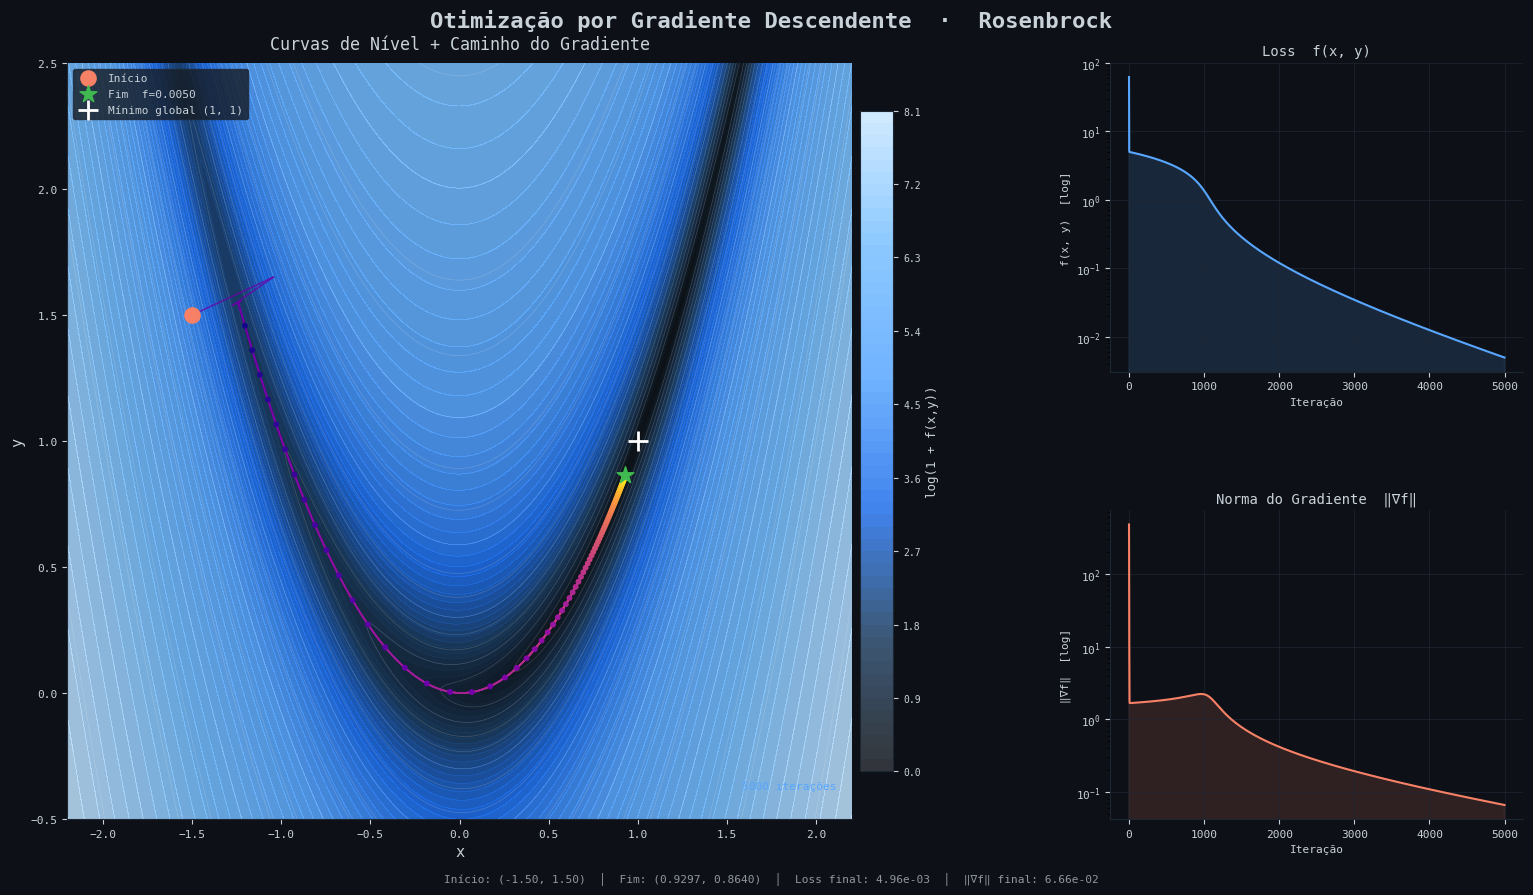


──────────────────────────────────────────────────



In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import rcParams

# ── Configuração visual ────────────────────────────────────────────────────────
rcParams["font.family"] = "monospace"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False

DARK_BG   = "#0d1117"
GRID_CLR  = "#1e2633"
TEXT_CLR  = "#c9d1d9"
ACCENT    = "#58a6ff"
WARM      = "#f78166"
HIGHLIGHT = "#3fb950"


def f(x, y):
    """Função de Rosenbrock — vale por ser não-convexa e desafiadora."""
    return (1 - x)**2 + 100 * (y - x**2)**2


def grad_f(x, y, eps=1e-5):
    """Gradiente numérico (funciona para qualquer função f)."""
    dfdx = (f(x + eps, y) - f(x - eps, y)) / (2 * eps)
    dfdy = (f(x, y + eps) - f(x, y - eps)) / (2 * eps)
    return np.array([dfdx, dfdy])


# ── Gradiente Descendente ──────────────────────────────────────────────────────
def gradient_descent(
    start: tuple[float, float],
    lr: float = 1e-3,
    max_iter: int = 5_000,
    tol: float = 1e-7,
) -> pd.DataFrame:
    """
    Minimiza f(x, y) por gradiente descendente.

    Retorna DataFrame com colunas: step, x, y, loss, grad_norm
    """
    x, y = float(start[0]), float(start[1])
    history = []

    for step in range(max_iter):
        loss = f(x, y)
        g    = grad_f(x, y)
        gnorm = float(np.linalg.norm(g))

        history.append({"step": step, "x": x, "y": y,
                         "loss": loss, "grad_norm": gnorm})

        if gnorm < tol:
            print(f"  Convergiu em {step} iterações  ✓")
            break

        x -= lr * g[0]
        y -= lr * g[1]
    else:
        print(f"  Máximo de iterações atingido ({max_iter})")

    return pd.DataFrame(history)


# ── Grade para curvas de nível ─────────────────────────────────────────────────
def build_grid(x_range, y_range, n=400):
    xs = np.linspace(*x_range, n)
    ys = np.linspace(*y_range, n)
    X, Y = np.meshgrid(xs, ys)
    Z = f(X, Y)
    return X, Y, Z


# ── Plot principal ─────────────────────────────────────────────────────────────
def plot_optimization(df: pd.DataFrame, x_range, y_range):
    X, Y, Z = build_grid(x_range, y_range)
    Z_log   = np.log1p(Z)               # escala log para visualizar melhor

    # Colormap customizado
    cmap = LinearSegmentedColormap.from_list(
        "deep_ocean",
        ["#0d1117", "#1a3a5c", "#1f6feb", "#58a6ff", "#79c0ff", "#cae8ff"],
    )

    fig = plt.figure(figsize=(16, 9), facecolor=DARK_BG)
    fig.suptitle(
        "Otimização por Gradiente Descendente  ·  Rosenbrock",
        color=TEXT_CLR, fontsize=16, fontweight="bold", y=0.98,
    )

    gs = fig.add_gridspec(2, 2, width_ratios=[2, 1],
                          hspace=0.45, wspace=0.35,
                          left=0.06, right=0.97, top=0.92, bottom=0.08)

    ax_main = fig.add_subplot(gs[:, 0])   # curvas de nível + caminho
    ax_loss = fig.add_subplot(gs[0, 1])   # curva de loss
    ax_grad = fig.add_subplot(gs[1, 1])   # norma do gradiente

    # ── Painel esquerdo: curvas de nível ───────────────────────────────────────
    for ax in [ax_main, ax_loss, ax_grad]:
        ax.set_facecolor(DARK_BG)
        for sp in ax.spines.values():
            sp.set_color(GRID_CLR)
        ax.tick_params(colors=TEXT_CLR, labelsize=8)
        ax.xaxis.label.set_color(TEXT_CLR)
        ax.yaxis.label.set_color(TEXT_CLR)
        ax.title.set_color(TEXT_CLR)

    contourf = ax_main.contourf(X, Y, Z_log, levels=60, cmap=cmap, alpha=0.85)
    contour  = ax_main.contour( X, Y, Z_log, levels=20,
                                 colors="white", alpha=0.18, linewidths=0.5)

    cbar = fig.colorbar(contourf, ax=ax_main, pad=0.01, fraction=0.04)
    cbar.set_label("log(1 + f(x,y))", color=TEXT_CLR, fontsize=9)
    cbar.ax.yaxis.set_tick_params(color=TEXT_CLR)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_CLR, fontsize=7)
    cbar.outline.set_edgecolor(GRID_CLR)

    # Caminho percorrido
    n_pts = len(df)
    colors_path = plt.cm.plasma(np.linspace(0.2, 1.0, n_pts))

    for i in range(n_pts - 1):
        ax_main.plot(
            df["x"].iloc[i:i+2],
            df["y"].iloc[i:i+2],
            color=colors_path[i], lw=1.2, alpha=0.7,
        )

    # Scatter com subsample para não poluir
    step_sample = max(1, n_pts // 80)
    sc = ax_main.scatter(
        df["x"].iloc[::step_sample],
        df["y"].iloc[::step_sample],
        c=np.linspace(0, 1, len(df.iloc[::step_sample])),
        cmap="plasma", s=18, zorder=5, edgecolors="none",
    )

    # Ponto inicial e final
    ax_main.scatter(*df[["x","y"]].iloc[0],  s=120, color=WARM,
                    marker="o", zorder=10, label="Início")
    ax_main.scatter(*df[["x","y"]].iloc[-1], s=160, color=HIGHLIGHT,
                    marker="*", zorder=10, label=f"Fim  f={df['loss'].iloc[-1]:.4f}")
    ax_main.scatter(1, 1, s=200, color="white", marker="+",
                    linewidths=2, zorder=11, label="Mínimo global (1, 1)")

    ax_main.set_xlabel("x", fontsize=11)
    ax_main.set_ylabel("y", fontsize=11)
    ax_main.set_title("Curvas de Nível + Caminho do Gradiente", fontsize=12, pad=10)
    ax_main.set_xlim(x_range)
    ax_main.set_ylim(y_range)
    ax_main.legend(fontsize=8, facecolor="#161b22", edgecolor=GRID_CLR,
                   labelcolor=TEXT_CLR, loc="upper left")

    # Anotação de iterações
    ax_main.annotate(
        f"{n_pts} iterações",
        xy=(0.98, 0.04), xycoords="axes fraction",
        ha="right", fontsize=8, color=ACCENT,
    )

    # ── Loss curve ────────────────────────────────────────────────────────────
    ax_loss.plot(df["step"], df["loss"], color=ACCENT, lw=1.5)
    ax_loss.fill_between(df["step"], df["loss"], alpha=0.15, color=ACCENT)
    ax_loss.set_yscale("log")
    ax_loss.set_title("Loss  f(x, y)", fontsize=10)
    ax_loss.set_xlabel("Iteração", fontsize=8)
    ax_loss.set_ylabel("f(x, y)  [log]", fontsize=8)
    ax_loss.grid(True, color=GRID_CLR, lw=0.5)

    # ── Grad norm ─────────────────────────────────────────────────────────────
    ax_grad.plot(df["step"], df["grad_norm"], color=WARM, lw=1.5)
    ax_grad.fill_between(df["step"], df["grad_norm"], alpha=0.15, color=WARM)
    ax_grad.set_yscale("log")
    ax_grad.set_title("Norma do Gradiente  ‖∇f‖", fontsize=10)
    ax_grad.set_xlabel("Iteração", fontsize=8)
    ax_grad.set_ylabel("‖∇f‖  [log]", fontsize=8)
    ax_grad.grid(True, color=GRID_CLR, lw=0.5)

    # ── Rodapé com estatísticas ───────────────────────────────────────────────
    stats = (
        f"Início: ({df['x'].iloc[0]:.2f}, {df['y'].iloc[0]:.2f})  │  "
        f"Fim: ({df['x'].iloc[-1]:.4f}, {df['y'].iloc[-1]:.4f})  │  "
        f"Loss final: {df['loss'].iloc[-1]:.2e}  │  "
        f"‖∇f‖ final: {df['grad_norm'].iloc[-1]:.2e}"
    )
    fig.text(0.5, 0.01, stats, ha="center", fontsize=8,
             color=TEXT_CLR, alpha=0.7)
    plt.show()


# ── Execução ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    START    = (-1.5, 1.5)
    LR       = 1e-3
    MAX_ITER = 5_000

    print(f"\n{'─'*50}")
    print(f"  Função:   Rosenbrock  f(x,y) = (1-x)² + 100(y-x²)²")
    print(f"  Início:   {START}")
    print(f"  LR:       {LR}   |   Max iter: {MAX_ITER}")
    print(f"{'─'*50}")

    df = gradient_descent(start=START, lr=LR, max_iter=MAX_ITER)

    print(f"\n  Primeiras linhas do histórico:")
    print(df.head(5).to_string(index=False))
    print(f"\n  Últimas linhas:")
    print(df.tail(5).to_string(index=False))

    plot_optimization(df, x_range=(-2.2, 2.2), y_range=(-0.5, 2.5))
    print(f"\n{'─'*50}\n")